# Credit Scoring Model
## Project Objective

The objective of this project is to predict an individual's creditworthiness based on demographic and financial information. Machine Learning classification algorithms are used to classify credit scores into High, Average, and Low categories.

# 1.Importing Required Libraries

Libraries are imported to perform data analysis, visualization, data preprocessing, model training, and model evaluation.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# 2.Loading the Dataset

The dataset is loaded using the Pandas library. After loading, we display the first few rows to understand the structure of the dataset.

In [3]:
# Load dataset
df = pd.read_csv(r"C:\Users\hp\Desktop\Credit Score Classification Dataset.csv")

# Display first 5 rows
df.head()

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25,Female,50000,Bachelor's Degree,Single,0,Rented,High
1,30,Male,100000,Master's Degree,Married,2,Owned,High
2,35,Female,75000,Doctorate,Married,1,Owned,High
3,40,Male,125000,High School Diploma,Single,0,Owned,High
4,45,Female,100000,Bachelor's Degree,Married,3,Owned,High


## Step 3: Understand the Dataset

Before building a model, we must understand:

Number of rows and columns,
Data types,
Missing values,
Basic statistics

In [4]:
# Number of rows and columns
df.shape

(164, 8)

## Dataset Information

The info() function provides information about column names, data types, and non-null values.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 164 non-null    int64 
 1   Gender              164 non-null    object
 2   Income              164 non-null    int64 
 3   Education           164 non-null    object
 4   Marital Status      164 non-null    object
 5   Number of Children  164 non-null    int64 
 6   Home Ownership      164 non-null    object
 7   Credit Score        164 non-null    object
dtypes: int64(3), object(5)
memory usage: 10.4+ KB


### Statistical Summary

The describe() function provides statistical information about numerical columns such as mean, minimum value, maximum value, and standard deviation.

In [6]:
df.describe()

,Age,Income,Number of Children
count,164.000000,164.000000,164.000000
mean,37.975610,83765.243902,0.652439
std,8.477289,32457.306728,0.883346
min,25.000000,25000.000000,0.000000
25%,30.750000,57500.000000,0.000000
50%,37.000000,83750.000000,0.000000
75%,45.000000,105000.000000,1.000000
max,53.000000,162500.000000,3.000000


### Display Column Names

This helps us quickly view all available features in the dataset.

In [7]:
df.columns

Index(['Age', 'Gender', 'Income', 'Education', 'Marital Status',
       'Number of Children', 'Home Ownership', 'Credit Score'],
      dtype='object')

### Checking Credit Score Categories

This helps us understand the target classes available in the dataset.

In [8]:
df["Credit Score"].value_counts()

Credit Score
High       113
Average     36
Low         15
Name: count, dtype: int64

### Observation:

The dataset is imbalanced because the majority of records belong to the High credit score category. Therefore, evaluation metrics such as Precision, Recall, and F1-Score will be used along with Accuracy.

# Step 4: Data Cleaning

Even though the dataset looks clean, we should still verify it. This shows a proper ML workflow.

In [9]:
# Check missing values
df.isnull().sum()

Age                   0
Gender                0
Income                0
Education             0
Marital Status        0
Number of Children    0
Home Ownership        0
Credit Score          0
dtype: int64

In [10]:
# Check duplicate rows
df.duplicated().sum()

np.int64(62)

In [11]:
# Remove duplicates if present
df = df.drop_duplicates()

# Check dataset shape after removing duplicates
df.shape

(102, 8)

In [12]:
df["Credit Score"].value_counts()

Credit Score
High       75
Average    21
Low         6
Name: count, dtype: int64

### Observation

After removing duplicate records, the dataset contains 102 unique observations.

The target variable is imbalanced, with most records belonging to the High credit score category. Therefore, model performance will be evaluated using Precision, Recall, and F1-Score in addition to Accuracy.

# Step 5: Exploratory Data Analysis (EDA)

Now we'll understand the data visually.

## Credit Score Distribution

A countplot is used to visualize the number of records present in each credit score category. This helps us understand the distribution of the target variable.

Why are we using Countplot?

A countplot shows the number of observations in each category.

It helps us:

Understand class distribution
Detect imbalance in the target variable
Know whether one class dominates others

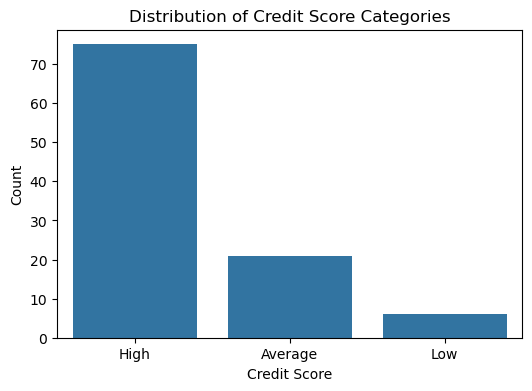

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(x='Credit Score', data=df)

plt.title("Distribution of Credit Score Categories")
plt.xlabel("Credit Score")
plt.ylabel("Count")

plt.show()

## Income Distribution

A histogram is used to understand how income values are distributed among individuals in the dataset.

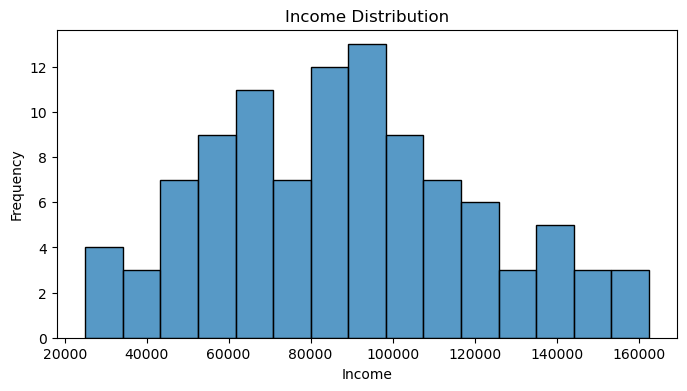

In [14]:
plt.figure(figsize=(8,4))

sns.histplot(df['Income'], bins=15)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.show()

Why Histplot?

A histogram helps us understand:

Distribution of income values
Common income ranges
Whether the data is skewed
Presence of unusual values

### Observation:

The income values are distributed across a wide range. Most individuals have incomes between 60,000 and 110,000. No significant outliers are observed in the dataset.

## Age Distribution

This histogram shows how individuals are distributed across different age groups.

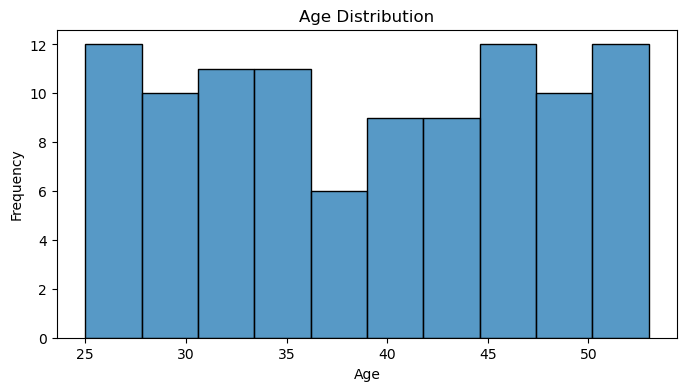

In [15]:
plt.figure(figsize=(8,4))

sns.histplot(df['Age'], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

### Observation:

The age distribution appears relatively balanced. Individuals from different age groups are represented in the dataset, which can help the model learn patterns across a diverse population.

### 5.4 Gender vs Credit Score

This graph is useful because it compares two categorical variables.

### Gender and Credit Score

This visualization helps analyze the relationship between gender and credit score categories.

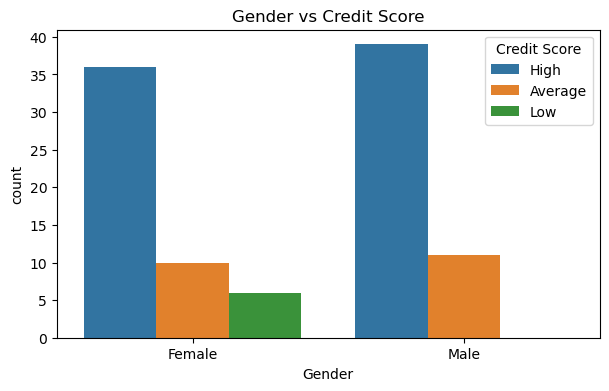

In [16]:
plt.figure(figsize=(7,4))

sns.countplot(x='Gender', hue='Credit Score', data=df)

plt.title("Gender vs Credit Score")

plt.show()

## Income Distribution Across Credit Score Categories

A boxplot is used to compare income levels across different credit score categories. It helps identify whether income influences creditworthiness.

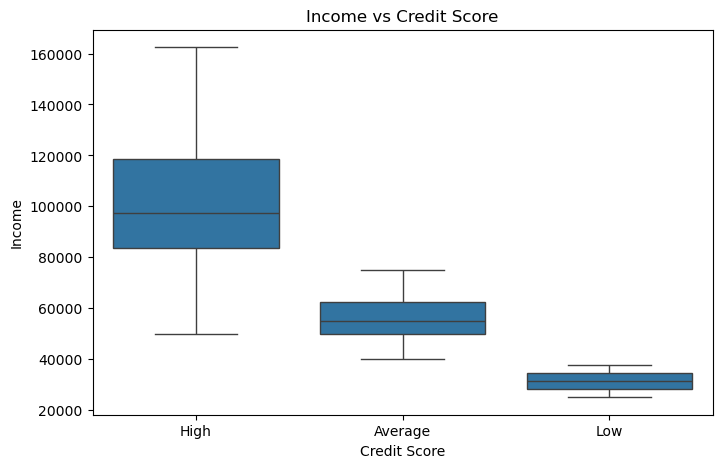

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Credit Score', y='Income', data=df)

plt.title("Income vs Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Income")

plt.show()

### What does the boxplot tell us?
People with High Credit Score generally have the highest income.
People with Average Credit Score have moderate income.
People with Low Credit Score have the lowest income range.
There is a clear separation between the three categories.

This is a very good sign because it suggests that Income is an important feature for predicting Credit Score.

## Step 6: Feature Engineering

# Feature Engineering

Feature engineering involves creating new features from existing data to provide additional information to the machine learning model.

### Create Income Per Child
Why?

Someone earning ₹100,000 with 0 children and someone earning ₹100,000 with 4 children may have different financial situations.

In [18]:
# Create a new feature

df["Income_Per_Child"] = df["Income"] / (df["Number of Children"] + 1)

# Display first few rows
df.head()

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score,Income_Per_Child
0,25,Female,50000,Bachelor's Degree,Single,0,Rented,High,50000.000000
1,30,Male,100000,Master's Degree,Married,2,Owned,High,33333.333333
2,35,Female,75000,Doctorate,Married,1,Owned,High,37500.000000
3,40,Male,125000,High School Diploma,Single,0,Owned,High,125000.000000
4,45,Female,100000,Bachelor's Degree,Married,3,Owned,High,25000.000000


Income_Per_Child represents the income available per dependent. It provides additional information about an individual's financial capacity and may help improve prediction performance.

# Step 7: Encoding Categorical Variables

Machine learning models cannot understand text values such as Male, Female, High, Low, etc.

Therefore, we convert categorical values into numerical form.

Categorical variables are converted into numerical values using Label Encoding so that machine learning algorithms can process them.

In [19]:
# Create LabelEncoder object
label_encoder = LabelEncoder()

# List of categorical columns
categorical_columns = [
    "Gender",
    "Education",
    "Marital Status",
    "Home Ownership",
    "Credit Score"
]

# Apply Label Encoding
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

# Display first few rows
df.head()

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score,Income_Per_Child
0,25,0,50000,1,1,0,1,1,50000.000000
1,30,1,100000,4,0,2,0,1,33333.333333
2,35,0,75000,2,0,1,0,1,37500.000000
3,40,1,125000,3,1,0,0,1,125000.000000
4,45,0,100000,1,0,3,0,1,25000.000000


Code Explanation:

1. LabelEncoder() is used to convert categorical values into numerical values.

2. A list named categorical_columns is created to store the names of all columns containing text data.

3. A for loop is used to apply Label Encoding to each categorical column one by one.

4. fit_transform() first identifies the unique categories in a column and then assigns a numerical value to each category.

5. The encoded values replace the original text values in the dataset.

6. Finally, df.head() is used to display the first few rows and verify that the encoding has been applied successfully.

In [20]:
for column in categorical_columns:
    print(column)
    print(df[column].unique())
    print()

Gender
[0 1]

Education
[1 4 2 3 0]

Marital Status
[1 0]

Home Ownership
[1 0]

Credit Score
[1 0 2]



In [21]:
print(df["Credit Score"].value_counts())

Credit Score
1    75
0    21
2     6
Name: count, dtype: int64


#### Observation:

After applying Label Encoding, the Credit Score categories were converted into numerical values.

Average → 0
High → 1
Low → 2

This conversion allows machine learning algorithms to process the target variable efficiently.

## Step 8: Define Features and Target

Before training a model, we separate:

Features (X) → Input variables
Target (y) → Output variable

#### Defining Features and Target Variable

The independent variables are stored in X, while the target variable (Credit Score) is stored in y.

In [22]:
# Features
X = df.drop("Credit Score", axis=1)

# Target
y = df["Credit Score"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (102, 8)
Target Shape: (102,)


# Step 9: Train-Test Split

## Splitting the Dataset

The dataset is divided into training and testing sets.

Training Data:
Used to train the machine learning model.

Testing Data:
Used to evaluate model performance on unseen data.

An 80:20 ratio is used for splitting the dataset.

In [23]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (81, 8)
Testing Data Shape: (21, 8)


Small Improvement

Since our dataset is imbalanced (75 High, 21 Average, 6 Low), I would actually use:

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

The stratify parameter ensures that the proportion of each credit score category remains similar in both the training and testing datasets. This helps create a more representative split, especially when the dataset is imbalanced.

# Step 10: Logistic Regression Model

### Logistic Regression Model

Logistic Regression is a supervised machine learning algorithm used for classification tasks.

It predicts the category of a data point based on the relationship between the input features and the target variable.

In this project, Logistic Regression is used to classify individuals into different credit score categories.

In [25]:
# Create Logistic Regression model
logistic_model = LogisticRegression()

# Train the model
logistic_model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Code Explanation:

1. LogisticRegression() creates a Logistic Regression model.

2. fit() trains the model using the training dataset.

3. During training, the model learns patterns between the input features and credit score categories.

4. Once training is completed, the model is ready to make predictions on new data.

### Making Predictions

After training the model, predictions are generated for the testing dataset.

In [26]:
# Predict credit scores
y_pred_lr = logistic_model.predict(X_test)

# Display first few predictions
print(y_pred_lr[:10])

[1 1 1 1 1 1 1 1 1 0]


The predict() function is used to generate predicted credit score categories for the testing dataset.

# Model Evaluation

The performance of the Logistic Regression model is evaluated using Accuracy, Precision, Recall, and F1-Score.

In [27]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred_lr)

precision = precision_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred_lr,
    average='weighted'
)

print("Accuracy :", round(accuracy, 2))
print("Precision:", round(precision, 2))
print("Recall   :", round(recall, 2))
print("F1 Score :", round(f1, 2))

Accuracy : 0.76
Precision: 0.74
Recall   : 0.76
F1 Score : 0.75


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The dataset is imbalanced, with very few samples belonging to the Low Credit Score category. As a result, some models may not predict this class, which can affect Precision and Recall values for minority classes.

In [28]:
print(classification_report(
    y_test,
    y_pred_lr,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.40      0.50      0.44         4
           1       0.88      0.88      0.88        16
           2       0.00      0.00      0.00         1

    accuracy                           0.76        21
   macro avg       0.42      0.46      0.44        21
weighted avg       0.74      0.76      0.75        21



### Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions made by the model for each class.

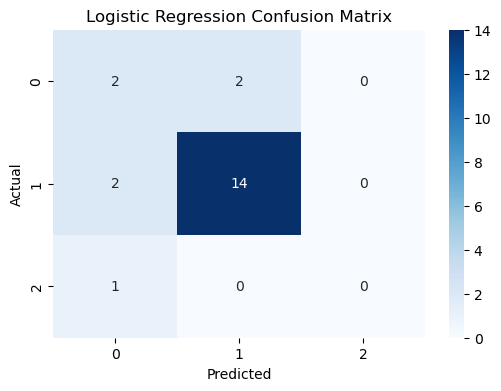

In [29]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

# Plot confusion matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Step 11: Decision Tree Classifier


Decision Tree is a supervised machine learning algorithm used for classification and prediction tasks.

It works by creating a tree-like structure of decisions based on feature values. The model learns decision rules from the training data and uses these rules to classify new observations.

In [30]:
# Create Decision Tree model
decision_tree = DecisionTreeClassifier(random_state=42)

# Train the model
decision_tree.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [31]:
# Generate predictions
y_pred_dt = decision_tree.predict(X_test)

# Display first few predictions
print(y_pred_dt[:10])

[1 1 1 1 1 1 1 1 1 0]


In [32]:
# Calculate evaluation metrics

dt_accuracy = accuracy_score(y_test, y_pred_dt)

dt_precision = precision_score(
    y_test,
    y_pred_dt,
    average='weighted',
    zero_division=0
)

dt_recall = recall_score(
    y_test,
    y_pred_dt,
    average='weighted'
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt,
    average='weighted'
)

print("Accuracy :", round(dt_accuracy, 2))
print("Precision:", round(dt_precision, 2))
print("Recall   :", round(dt_recall, 2))
print("F1 Score :", round(dt_f1, 2))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [33]:
print(classification_report(
    y_test,
    y_pred_dt,
    zero_division=0
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00        16
           2       1.00      1.00      1.00         1

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



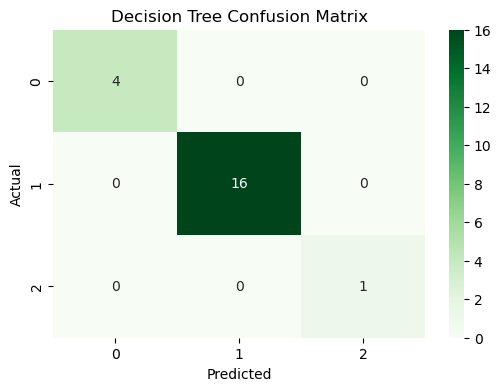

In [34]:
# Generate confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Plot confusion matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [35]:
print("Tree Depth:", decision_tree.get_depth())
print("Number of Leaves:", decision_tree.get_n_leaves())

Tree Depth: 5
Number of Leaves: 7


# Step 12: Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.

Each tree makes a prediction, and the final output is determined by majority voting.

In [36]:
# Create Random Forest model
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [37]:
# Generate predictions
y_pred_rf = random_forest.predict(X_test)

In [38]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average='weighted',
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

print("Accuracy :", round(rf_accuracy, 2))
print("Precision:", round(rf_precision, 2))
print("Recall   :", round(rf_recall, 2))
print("F1 Score :", round(rf_f1, 2))

Accuracy : 0.95
Precision: 0.96
Recall   : 0.95
F1 Score : 0.95


### Model Comparison

Three machine learning models were trained and evaluated for credit score classification.

Logistic Regression achieved an accuracy of 76%.

Decision Tree achieved 100% accuracy on the testing dataset. However, the perfect score may indicate overfitting due to the small size of the dataset.

Random Forest achieved 95% accuracy and provided strong overall performance while reducing the risk of overfitting.

Therefore, Random Forest can be considered the most reliable model for this credit scoring task.

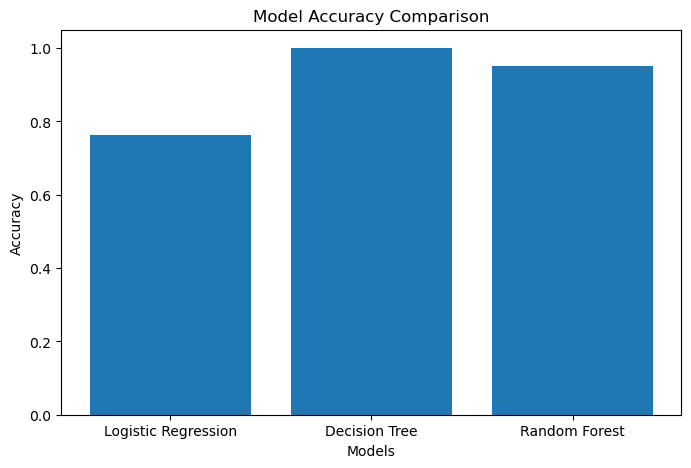

In [39]:
models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

accuracies = [
    accuracy,
    dt_accuracy,
    rf_accuracy
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

In [40]:
df.shape

(102, 9)

#### Dataset Summary

The original dataset contained 164 records and 8 features.

During data cleaning, 62 duplicate records were identified and removed, resulting in 102 unique observations.

A new feature named Income_Per_Child was created through feature engineering, increasing the total number of features from 8 to 9.

The final dataset used for model training and evaluation consisted of 102 records and 9 features.

# Conclusion

In this project, a Credit Scoring Model was developed to predict an individual's creditworthiness using demographic and financial information.

The dataset was cleaned, analyzed, and preprocessed using feature engineering and label encoding techniques.

Three machine learning algorithms were implemented:

1. Logistic Regression
2. Decision Tree
3. Random Forest

Among the evaluated models, Random Forest provided the most reliable performance with an accuracy of 95%, while Decision Tree achieved perfect accuracy but may be prone to overfitting due to the small dataset size.

The project demonstrates how machine learning can be used to support credit risk assessment and decision-making processes.